# Многофакторный анализ ценовых моделей и интерфейсов оформления заказа (Factorial ANOVA)
### Бизнес-контекст и формулировка гипотез:
Сервис доставки еды (FastBite) тестирует влияние комбинаций **ценовых моделей (Pricing Models)** и **интерфейсов оформления заказа (Checkout Layouts)** на чистую маржинальность (`net_margin_usd`) в разрезе категорий городов (`city_tier`).
**Тестируемые факторы:**
1. **Ценообразование (`pricing_model`):** `fixed_low_fee`, `dynamic_surge_multiplier`, `tiered_basket_subsidy`.
2. **UX чекаута (`checkout_layout`):** `one_click_express`, `upsell_grid_modal`, `gamified_loyalty_bar`.
**Проверяемые гипотезы:**
* **$H_1$ (Главные эффекты):** Существуют статистически значимые различия в средней маржинальности между отдельными моделями ценообразования и вариантами чекаута.
* **$H_2$ (Эффект взаимодействия):** Эффективность интерфейса чекаута зависит от применяемой модели цены (наличие кросс-факторного взаимодействия $Pricing \times Layout$).

In [3]:
import pandas as pd 
import seaborn as sns 
import pingouin as pg 

df = pd.read_csv('fastbite_orders_experiment.csv')

### 1. Предобработка данных и фильтрация аномалий
Исключены транзакции с некорректным временем доставки ($\le 0$), отрицательной стоимостью корзины и выбросами по чистой марже (`net_margin_usd` $\notin (0, 100)$).

In [26]:
df_clean = (
    df.query('delivery_time_min > 0 and basket_value_usd > 0 and  net_margin_usd > 0 and net_margin_usd < 100')
)
df_clean.head()

,order_id,order_hour,city_tier,pricing_model,checkout_layout,basket_value_usd,delivery_time_min,net_margin_usd
1,ORD-500001,18,tier_2_regional,dynamic_surge_multiplier,gamified_loyalty_bar,26.64,55.0,10.56
2,ORD-500002,15,tier_2_regional,fixed_low_fee,upsell_grid_modal,45.36,24.0,6.08
3,ORD-500003,20,tier_1_megacity,fixed_low_fee,one_click_express,42.49,35.0,3.27
4,ORD-500004,13,tier_1_megacity,dynamic_surge_multiplier,gamified_loyalty_bar,30.67,29.0,10.51
5,ORD-500005,12,tier_1_megacity,tiered_basket_subsidy,one_click_express,42.82,36.0,7.00


In [13]:
df_clean.pricing_model.value_counts()

pricing_model
fixed_low_fee               1191
dynamic_surge_multiplier    1138
tiered_basket_subsidy       1057
Name: count, dtype: int64

### 2. Проверка статистических предпосылок (Нормальность и гомоскедастичность)
Перед выбором параметрических критериев проверяем:
1. **Нормальность распределений:** тест Д’Агостино-Пирсона (`normaltest`).
2. **Равенство дисперсий:** тест Левена (`levene`).

In [12]:
morn_test = pg.normality(data = df_clean, group = 'pricing_model', dv = 'net_margin_usd', method = 'normaltest')
morn_test

,W,pval,normal
pricing_model,,,
dynamic_surge_multiplier,40.811050,1.374020e-09,False
fixed_low_fee,3.298463,1.921976e-01,True
tiered_basket_subsidy,1895.847187,0.000000e+00,False


In [20]:
pg.homoscedasticity(data = df_clean, dv = 'net_margin_usd', group = 'pricing_model', method = 'levene' )


,W,pval,equal_var
levene,149.253387,7.621142e-63,False


> **Вывод по предпосылкам:** Тест Левена отвергает гипотезу о равенстве дисперсий ($p < 0.001$), распределения в группах отклоняются от нормального. В связи с гетероскедастичностью классическая ANOVA неприменима — используем **критерий Уэлча (Welch's ANOVA)** и post-hoc критерий **Геймса-Хоуэлла (Games-Howell)**.

In [21]:
#так как не все они нормальные а дисперсии не равны будем использовать анову велча
pg.welch_anova(data = df_clean, between = 'pricing_model', dv = 'net_margin_usd')

,Source,ddof1,ddof2,F,p_unc,np2
0,pricing_model,2,1905.833481,143.076288,1.281169e-58,0.054976


In [ ]:
pg.pairwise_gameshowell(data = df_clean, between = 'pricing_model',dv = 'net_margin_usd')

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,dynamic_surge_multiplier,fixed_low_fee,6.504350,4.790277,1.714073,0.122784,13.960048,1626.786945,6.240564e-13,0.586716
1,dynamic_surge_multiplier,tiered_basket_subsidy,6.504350,6.320681,0.183669,0.161972,1.133954,2171.917820,4.932191e-01,0.048468
2,fixed_low_fee,tiered_basket_subsidy,4.790277,6.320681,-1.530404,0.129189,-11.846202,1465.807581,0.000000e+00,-0.519726


### 3. Двухфакторный дисперсионный анализ (Two-Way Factorial ANOVA)
Оцениваем влияние ценовой модели, типа чекаута и их совместного взаимодействия на маржинальность.

In [ ]:
pg.anova(data = df_clean, between = ['pricing_model','checkout_layout'], dv = 'net_margin_usd')
#np2 целых 16 процентов тоесть выручка очень сильно зависит от checkout_layout

,Source,SS,DF,MS,F,p_unc,np2
0,pricing_model,2090.168747,2.0,1045.084374,123.030807,2.662829e-52,0.067915
1,checkout_layout,1070.260770,2.0,535.130385,62.997328,1.376077e-27,0.035968
2,pricing_model * checkout_layout,5634.218122,4.0,1408.554531,165.819722,8.779936e-130,0.164167
3,Residual,28685.904195,3377.0,8.494493,NaN,NaN,NaN


> **Интерпретация ANOVA:** Обнаружен сильный статистически значимый эффект взаимодействия факторов ($F(4, 3377) = 165.82, p < 0.001$). Размер эффекта np2 = 16.4\%$ указывает на то, что выбор оптимального чекаута критически зависит от ценовой модели.

<Axes: xlabel='pricing_model', ylabel='net_margin_usd'>

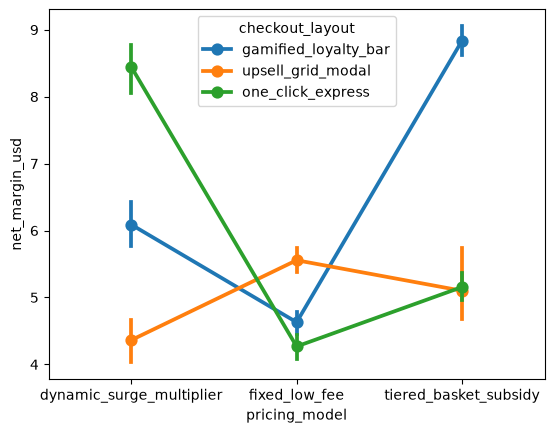

In [35]:
sns.pointplot(data = df_clean, x = 'pricing_model', y = 'net_margin_usd',hue = 'checkout_layout')

### строим поинтплот в разрезе по городам

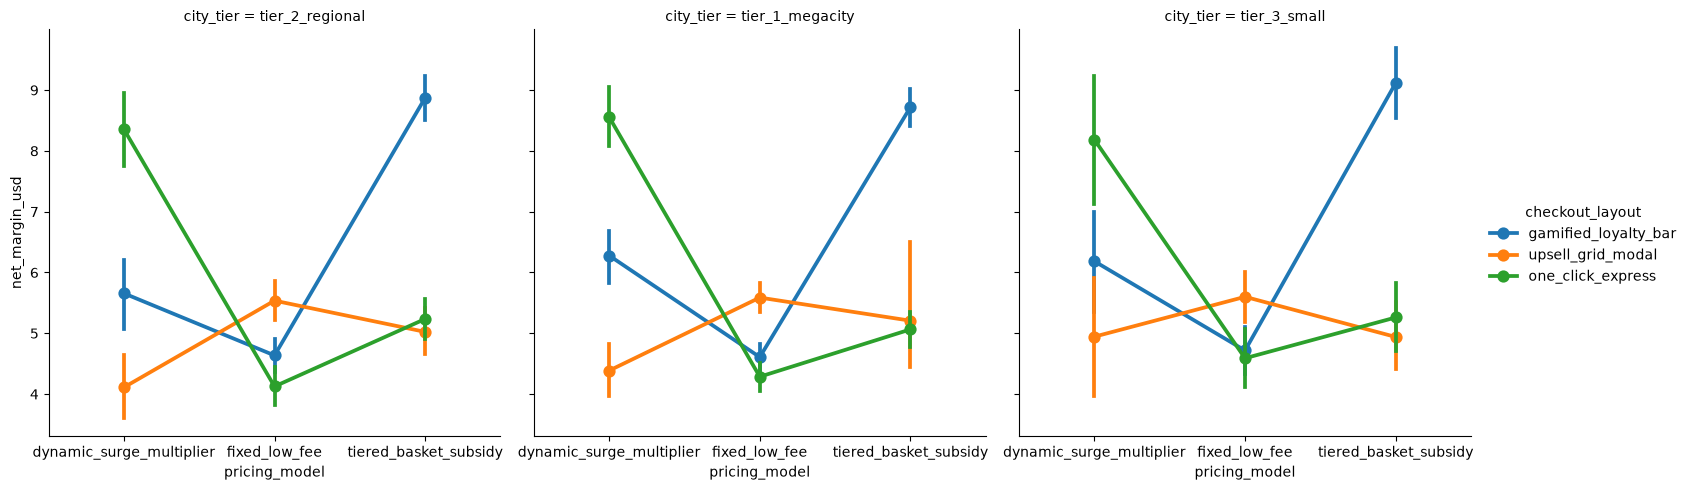

In [37]:
sns.catplot(data = df_clean, x ='pricing_model', y = 'net_margin_usd', hue = 'checkout_layout', col = 'city_tier',kind = 'point')

## Итоговые выводы и матрица продуктовых решений

### 1. Аналитические результаты:
1. **Динамический серж (`dynamic_surge_multiplier`):**
   * Максимальная маржа достигается **только при быстром чекауте (`one_click_express`)** ($\approx \$8.5$).
   * Попытка навязать допродажи (`upsell_grid_modal`) при повышенном спросе разрушает конверсию и обваливает маржу до минимальных значений ($\approx \$4.3$).
2. **Субсидирование корзины (`tiered_basket_subsidy`):**
   * Максимальная доходность ($\approx \$8.9$) достигается в связке с **геймификацией (`gamified_loyalty_bar`)**. Прогресс-бар стимулирует пользователей добирать корзину до порога субсидии.
3. **Фиксированная низкая комиссия (`fixed_low_fee`):**
   * Оптимально работает сетка допродаж (`upsell_grid_modal`), компенсируя низкую базовую комиссию за счет кросс-сейла.
4. **Региональный срез:** Закономерность сохраняется во всех типах городов (`tier_1`, `tier_2`, `tier_3`).

---

### 2. Рекомендации для внедрения:
Внедрить **динамическую маршрутизацию UX чекаута** в зависимости от контекста заказа:
* При активном Surge-коэффициенте ---> принудительно переключать пользователя на `one_click_express`.
* При акциях с пороговой скидкой на доставку ---> активировать `gamified_loyalty_bar`.
* При стандартных тарифах ---> показывать `upsell_grid_modal`.